In [1]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
from scipy import stats

In [2]:
df = pd.read_excel(r'C:\Users\MCHARO\Downloads\Primary Income Africa 2026.xlsx', engine='openpyxl')
df.head()

c:\Users\MCHARO\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Country Code,Country English,Country French,Unnamed: 3,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DZA,Algeria,Algérie,NaN,NaN,NaN,NaN,NaN,NaN,6.515000e+09,...,6.599906e+09,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,NaN
1,AGO,Angola,Angola,NaN,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,...,6.073893e+09,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09
2,BEN,Benin,Bénin,NaN,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,...,1.623390e+08,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,NaN
3,BWA,Botswana,Botswana,NaN,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,...,7.010919e+08,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08
4,BFA,Burkina Faso,Burkina Faso,NaN,NaN,NaN,NaN,NaN,NaN,5.860125e+07,...,4.967933e+08,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,NaN


DATA EXPLORATION

In [3]:
print("Dataset Shape:", df.shape)
print(f"\nTotal Records: {len(df):,}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

Dataset Shape: (50, 29)

Total Records: 50
Memory Usage: 0.02 MB


In [4]:
print("Column Names and Types:")
print(df.dtypes)
print("\nFirst 10 Rows:")
df.head()

Column Names and Types:
Country Code        object
Country English     object
Country French      object
Unnamed: 3         float64
2000               float64
2001               float64
2002               float64
2003               float64
2004               float64
2005               float64
2006               float64
2007               float64
2008               float64
2009               float64
2010               float64
2011               float64
2012               float64
2013               float64
2014               float64
2015               float64
2016               float64
2017               float64
2018               float64
2019               float64
2020               float64
2021               float64
2022               float64
2023               float64
2024               float64
dtype: object

First 10 Rows:


,Country Code,Country English,Country French,Unnamed: 3,2000,2001,2002,2003,2004,2005,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DZA,Algeria,Algérie,NaN,NaN,NaN,NaN,NaN,NaN,6.515000e+09,...,6.599906e+09,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,NaN
1,AGO,Angola,Angola,NaN,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,...,6.073893e+09,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09
2,BEN,Benin,Bénin,NaN,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,...,1.623390e+08,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,NaN
3,BWA,Botswana,Botswana,NaN,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,...,7.010919e+08,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08
4,BFA,Burkina Faso,Burkina Faso,NaN,NaN,NaN,NaN,NaN,NaN,5.860125e+07,...,4.967933e+08,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,NaN


In [5]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Unnamed: 3,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,0.0,3.700000e+01,3.700000e+01,3.700000e+01,3.900000e+01,4.000000e+01,4.500000e+01,4.400000e+01,4.500000e+01,4.500000e+01,...,4.900000e+01,4.800000e+01,4.700000e+01,4.700000e+01,4.800000e+01,4.800000e+01,4.700000e+01,4.600000e+01,4.100000e+01,1.800000e+01
mean,NaN,5.611020e+08,5.635428e+08,5.406811e+08,5.894410e+08,6.467923e+08,9.112909e+08,1.191341e+09,1.539153e+09,1.803103e+09,...,1.508291e+09,1.360526e+09,1.779563e+09,2.021759e+09,2.033178e+09,1.578435e+09,2.166266e+09,2.655782e+09,2.851474e+09,4.943565e+09
std,NaN,1.087169e+09,1.141571e+09,9.625844e+08,1.298642e+09,1.301245e+09,1.808260e+09,2.345305e+09,3.437088e+09,3.975384e+09,...,3.212319e+09,2.609691e+09,3.284038e+09,3.803804e+09,3.760983e+09,2.869574e+09,3.917666e+09,4.774898e+09,4.884506e+09,6.054264e+09
min,NaN,3.639087e+06,4.450875e+06,4.478774e+06,3.730863e+06,3.653591e+06,4.897428e+06,3.120922e+06,2.289963e+06,2.011207e+06,...,-7.385860e+07,2.162347e+06,-8.732291e+07,2.519793e+06,3.215763e+06,3.326067e+06,4.046422e+06,3.629701e+06,7.715706e+06,2.630238e+07
25%,NaN,5.053332e+07,4.258369e+07,4.684356e+07,4.688415e+07,5.575961e+07,4.987739e+07,5.341733e+07,7.442783e+07,8.000574e+07,...,1.418037e+08,1.689774e+08,1.678736e+08,1.819576e+08,1.917681e+08,1.520751e+08,2.235057e+08,2.566500e+08,3.284782e+08,3.451809e+08
50%,NaN,1.232000e+08,1.677115e+08,1.654128e+08,1.428206e+08,1.805982e+08,1.817205e+08,1.885592e+08,3.047966e+08,3.031738e+08,...,3.695732e+08,4.467565e+08,5.451761e+08,5.132041e+08,5.955764e+08,4.916666e+08,6.727800e+08,9.258610e+08,1.093380e+09,2.570677e+09
75%,NaN,7.294153e+08,5.811025e+08,6.379800e+08,5.838062e+08,8.544546e+08,9.940904e+08,1.196743e+09,1.262027e+09,1.327079e+09,...,8.926880e+08,1.069881e+09,1.515771e+09,1.692770e+09,1.484871e+09,1.396974e+09,1.721817e+09,1.807191e+09,2.163111e+09,7.681944e+09
max,NaN,5.695669e+09,6.266611e+09,4.975205e+09,7.448526e+09,7.576499e+09,9.569338e+09,1.123652e+10,1.672512e+10,1.740550e+10,...,1.575514e+10,1.418235e+10,1.665965e+10,1.938430e+10,1.829572e+10,1.361695e+10,1.941860e+10,2.000806e+10,2.017490e+10,1.859747e+10


In [6]:
print("Missing Values Analysis:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))
print(f"\nTotal Missing Values: {missing.sum():,}")

Missing Values Analysis:
            Missing_Count  Percentage
Unnamed: 3             50       100.0
2024                   32        64.0
2001                   13        26.0
2000                   13        26.0
2002                   13        26.0
2003                   11        22.0
2004                   10        20.0
2023                    9        18.0
2006                    6        12.0
2005                    5        10.0
2007                    5        10.0
2008                    5        10.0
2009                    4         8.0
2022                    4         8.0
2017                    3         6.0
2021                    3         6.0
2018                    3         6.0
2013                    3         6.0
2011                    3         6.0
2010                    3         6.0
2016                    2         4.0
2019                    2         4.0
2020                    2         4.0
2012                    2         4.0
2015                    1

In [7]:
# Drop fully-empty column if present
if 'Unnamed: 3' in df.columns:
    df.drop(columns=['Unnamed: 3'], inplace=True)

# Identify year columns (e.g. '2000', '2001', ...)
year_cols = [c for c in df.columns if isinstance(c, str) and c.isdigit()]
year_cols = sorted(year_cols, key=int)

# Ensure numeric
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors='coerce')

# Report missing before
print("Missing before:\n", df[year_cols].isnull().sum())

Missing before:
 2000    13
2001    13
2002    13
2003    11
2004    10
2005     5
2006     6
2007     5
2008     5
2009     4
2010     3
2011     3
2012     2
2013     3
2014     1
2015     1
2016     2
2017     3
2018     3
2019     2
2020     2
2021     3
2022     4
2023     9
2024    32
dtype: int64


In [8]:
# Interpolate across years (row-wise), allowing forward/backward interpolation
df[year_cols] = df[year_cols].interpolate(method='linear', axis=1, limit_direction='both')

# Fill any remaining NaNs with the column median
df[year_cols] = df[year_cols].fillna(df[year_cols].median())

# Report missing after
print("Missing after:\n", df[year_cols].isnull().sum())

Missing after:
 2000    0
2001    0
2002    0
2003    0
2004    0
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64


In [9]:
print("Missing Values Analysis:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))
print(f"\nTotal Missing Values: {missing.sum():,}")

Missing Values Analysis:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

Total Missing Values: 0


DATA TREATEMENT

In [10]:
data = pd.read_excel(r'C:\Users\MCHARO\OneDrive\Desktop\Income Analysis\df_clean_export.xlsx', engine='openpyxl')
data.head(10)

,Country Code,Country English,Country French,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,timestamp
0,DZA,Algeria,Algérie,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,7.052000e+09,...,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,6.113308e+09,NaN
1,AGO,Angola,Angola,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,6.322916e+09,...,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09,NaN
2,BEN,Benin,Bénin,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,5.409382e+07,...,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,5.333026e+08,NaN
3,BWA,Botswana,Botswana,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,1.302918e+09,...,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08,NaN
4,BFA,Burkina Faso,Burkina Faso,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,6.093499e+07,...,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,1.223188e+09,NaN
5,BDI,Burundi,Burundi,1.445149e+07,1.566454e+07,1.248124e+07,1.851194e+07,2.048197e+07,2.093729e+07,1.343766e+07,...,1.278882e+07,1.360222e+07,5.360469e+07,5.507595e+07,5.153584e+07,5.488107e+07,5.032044e+07,4.674557e+07,4.674557e+07,NaN
6,CPV,Cabo Verde,Cabo Verde,1.829621e+07,1.266150e+07,1.823598e+07,2.935552e+07,3.626500e+07,5.272444e+07,5.937039e+07,...,8.378382e+07,9.078880e+07,8.127838e+07,7.659582e+07,6.363806e+07,4.989688e+07,5.386952e+07,6.891546e+07,9.836491e+07,NaN
7,CMR,Cameroon,Cameroun,5.205992e+08,3.800841e+08,4.214982e+08,5.193527e+08,5.495261e+08,6.655466e+08,3.778050e+08,...,7.588728e+08,8.459492e+08,9.518873e+08,1.075004e+09,1.000896e+09,8.730687e+08,1.270146e+09,1.182201e+09,1.182201e+09,NaN
8,COM,Comoros,Comores,7.040326e+06,7.040326e+06,7.040326e+06,7.040326e+06,6.662393e+06,5.899701e+06,5.064453e+06,...,2.162347e+06,2.755354e+06,2.519793e+06,3.215763e+06,3.326067e+06,5.615210e+06,5.078685e+06,7.715706e+06,7.715706e+06,NaN
9,COG,Congo,Congo,8.213777e+08,6.946540e+08,8.705326e+08,5.976919e+08,9.635186e+08,1.596181e+09,1.774224e+09,...,4.045709e+08,7.616680e+08,1.118765e+09,1.475862e+09,8.961997e+07,1.711086e+09,1.711086e+09,1.711086e+09,1.711086e+09,NaN


In [11]:
# Identify The Year Columns Automatically (All 4 digit columns) and Apply USD Formatting across All year columns
# This will supress scientific notation globally and force standard decimal format
# Force those columns to remain numeric floats just in case they were to read as strings

data = pd.DataFrame(data)

#Identify The Year Columns Automatically (All 4 digit columns)
year_columns = [col for col in df.columns if col.isdigit()]

for col in year_columns:
    data[col] = pd.to_numeric(df[col], errors = 'coerce')

data.to_csv('cleaned_Africa_report')

data.head(10)

,Country Code,Country English,Country French,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,timestamp
0,DZA,Algeria,Algérie,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,7.052000e+09,...,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,6.113308e+09,NaN
1,AGO,Angola,Angola,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,6.322916e+09,...,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09,NaN
2,BEN,Benin,Bénin,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,5.409382e+07,...,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,5.333026e+08,NaN
3,BWA,Botswana,Botswana,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,1.302918e+09,...,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08,NaN
4,BFA,Burkina Faso,Burkina Faso,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,6.093499e+07,...,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,1.223188e+09,NaN
5,BDI,Burundi,Burundi,1.445149e+07,1.566454e+07,1.248124e+07,1.851194e+07,2.048197e+07,2.093729e+07,1.343766e+07,...,1.278882e+07,1.360222e+07,5.360469e+07,5.507595e+07,5.153584e+07,5.488107e+07,5.032044e+07,4.674557e+07,4.674557e+07,NaN
6,CPV,Cabo Verde,Cabo Verde,1.829621e+07,1.266150e+07,1.823598e+07,2.935552e+07,3.626500e+07,5.272444e+07,5.937039e+07,...,8.378382e+07,9.078880e+07,8.127838e+07,7.659582e+07,6.363806e+07,4.989688e+07,5.386952e+07,6.891546e+07,9.836491e+07,NaN
7,CMR,Cameroon,Cameroun,5.205992e+08,3.800841e+08,4.214982e+08,5.193527e+08,5.495261e+08,6.655466e+08,3.778050e+08,...,7.588728e+08,8.459492e+08,9.518873e+08,1.075004e+09,1.000896e+09,8.730687e+08,1.270146e+09,1.182201e+09,1.182201e+09,NaN
8,COM,Comoros,Comores,7.040326e+06,7.040326e+06,7.040326e+06,7.040326e+06,6.662393e+06,5.899701e+06,5.064453e+06,...,2.162347e+06,2.755354e+06,2.519793e+06,3.215763e+06,3.326067e+06,5.615210e+06,5.078685e+06,7.715706e+06,7.715706e+06,NaN
9,COG,Congo,Congo,8.213777e+08,6.946540e+08,8.705326e+08,5.976919e+08,9.635186e+08,1.596181e+09,1.774224e+09,...,4.045709e+08,7.616680e+08,1.118765e+09,1.475862e+09,8.961997e+07,1.711086e+09,1.711086e+09,1.711086e+09,1.711086e+09,NaN


In [12]:
data.columns

Index(['Country Code', 'Country English', 'Country French', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', 'timestamp'],
      dtype='object')

In [13]:
data = data.drop(columns = ['Country French', 'timestamp'])
data.head(10)

,Country Code,Country English,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DZA,Algeria,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,7.052000e+09,5.775368e+09,...,6.599906e+09,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,6.113308e+09
1,AGO,Angola,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,6.322916e+09,8.221585e+09,...,6.073893e+09,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09
2,BEN,Benin,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,5.409382e+07,8.619326e+07,...,1.623390e+08,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,5.333026e+08
3,BWA,Botswana,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,1.302918e+09,1.262027e+09,...,7.010919e+08,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08
4,BFA,Burkina Faso,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,6.093499e+07,6.580606e+07,...,4.967933e+08,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,1.223188e+09
5,BDI,Burundi,1.445149e+07,1.566454e+07,1.248124e+07,1.851194e+07,2.048197e+07,2.093729e+07,1.343766e+07,1.455638e+07,...,1.392772e+07,1.278882e+07,1.360222e+07,5.360469e+07,5.507595e+07,5.153584e+07,5.488107e+07,5.032044e+07,4.674557e+07,4.674557e+07
6,CPV,Cabo Verde,1.829621e+07,1.266150e+07,1.823598e+07,2.935552e+07,3.626500e+07,5.272444e+07,5.937039e+07,5.887032e+07,...,7.152780e+07,8.378382e+07,9.078880e+07,8.127838e+07,7.659582e+07,6.363806e+07,4.989688e+07,5.386952e+07,6.891546e+07,9.836491e+07
7,CMR,Cameroon,5.205992e+08,3.800841e+08,4.214982e+08,5.193527e+08,5.495261e+08,6.655466e+08,3.778050e+08,5.667820e+08,...,6.192368e+08,7.588728e+08,8.459492e+08,9.518873e+08,1.075004e+09,1.000896e+09,8.730687e+08,1.270146e+09,1.182201e+09,1.182201e+09
8,COM,Comoros,7.040326e+06,7.040326e+06,7.040326e+06,7.040326e+06,6.662393e+06,5.899701e+06,5.064453e+06,3.771678e+06,...,1.114330e+06,2.162347e+06,2.755354e+06,2.519793e+06,3.215763e+06,3.326067e+06,5.615210e+06,5.078685e+06,7.715706e+06,7.715706e+06
9,COG,Congo,8.213777e+08,6.946540e+08,8.705326e+08,5.976919e+08,9.635186e+08,1.596181e+09,1.774224e+09,1.450042e+09,...,1.245713e+08,4.045709e+08,7.616680e+08,1.118765e+09,1.475862e+09,8.961997e+07,1.711086e+09,1.711086e+09,1.711086e+09,1.711086e+09


DATA VISUALIZATION

C:\Users\MCHARO\AppData\Local\Temp\ipykernel_19076\4159916638.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.set_prop_cycle(color=plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(plot_named.columns))))


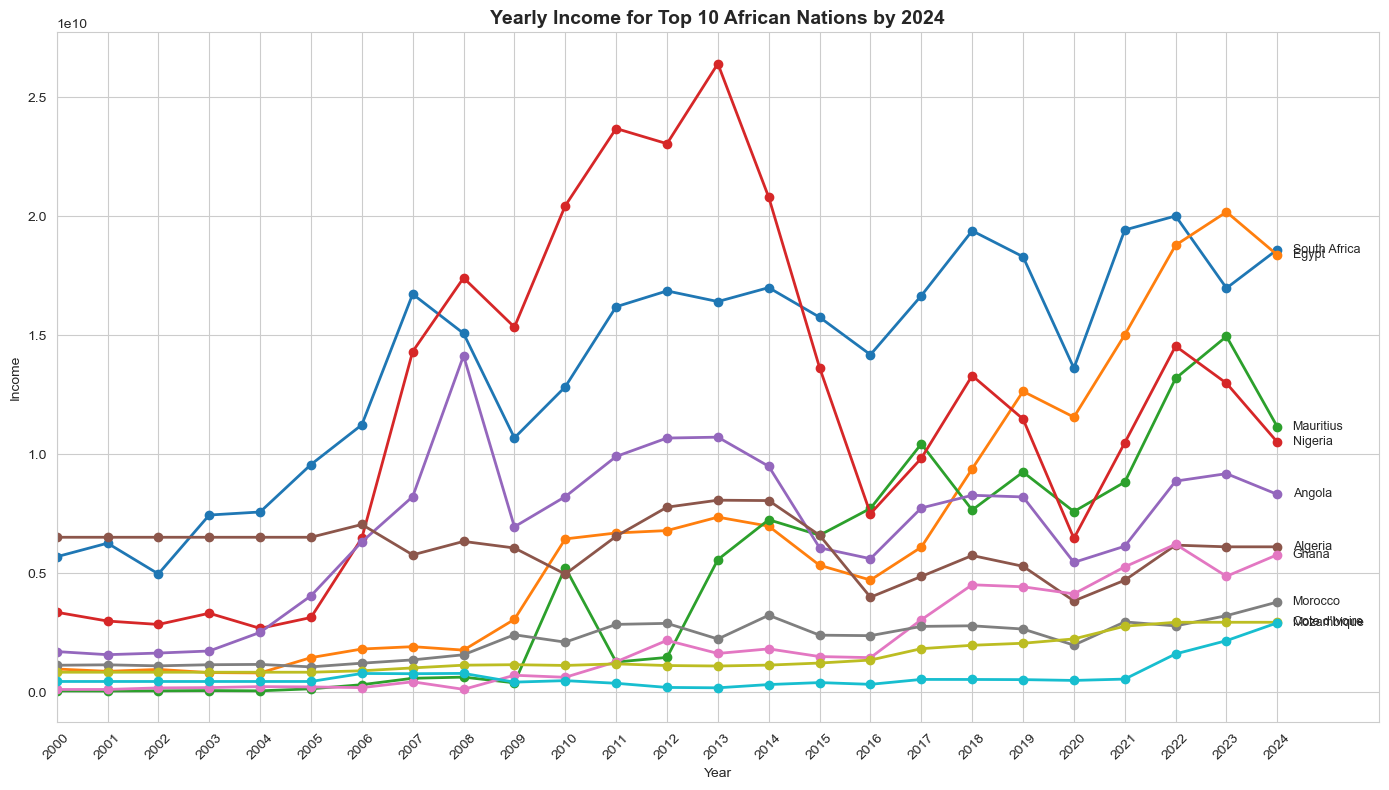

In [15]:
#The line graph below contains Yearly Incom of Top 10 African Countries
#Each country has a distinct color in the graph

plt.close('all')

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_style('whitegrid')
years = year_columns
latest_year = years[-1]

# select top 10 countries by latest year and prepare DataFrame for plotting (years as index)
top10 = data.sort_values(by=latest_year, ascending=False).head(10)
plot_named = top10.set_index('Country English')[years].T

# use colormap safely
ax.set_prop_cycle(color=plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(plot_named.columns))))

xs = [int(x) for x in plot_named.index]

for col in plot_named.columns:
    ys = plot_named[col].values
    ax.plot(xs, ys, marker='o', linewidth=2)
    ax.text(xs[-1] + 0.3, ys[-1], col, fontsize=9, va='center', ha='left')

ax.set_title(f'Yearly Income for Top 10 African Nations by {latest_year}', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Income')
ax.set_xticks(xs)
ax.set_xticklabels(xs, rotation=45)
ax.set_xlim(xs[0], xs[-1] + 2)

fig.tight_layout()
plt.show()

In [16]:
data.head(10)

,Country Code,Country English,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DZA,Algeria,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,6.515000e+09,7.052000e+09,5.775368e+09,...,6.599906e+09,3.997847e+09,4.868822e+09,5.749126e+09,5.295631e+09,3.841125e+09,4.710726e+09,6.184039e+09,6.113308e+09,6.113308e+09
1,AGO,Angola,1.715230e+09,1.583960e+09,1.652348e+09,1.738741e+09,2.521574e+09,4.056639e+09,6.322916e+09,8.221585e+09,...,6.073893e+09,5.614473e+09,7.745045e+09,8.278017e+09,8.208900e+09,5.459946e+09,6.138745e+09,8.873051e+09,9.186300e+09,8.315387e+09
2,BEN,Benin,3.582472e+07,3.583982e+07,4.684356e+07,6.098837e+07,5.997102e+07,4.318187e+07,5.409382e+07,8.619326e+07,...,1.623390e+08,1.484065e+08,1.506292e+08,1.618852e+08,1.947960e+08,3.336485e+08,4.923823e+08,4.385278e+08,5.333026e+08,5.333026e+08
3,BWA,Botswana,7.294153e+08,5.811025e+08,9.801052e+08,1.098448e+09,1.241679e+09,1.319848e+09,1.302918e+09,1.262027e+09,...,7.010919e+08,1.513024e+09,1.630259e+09,1.826229e+09,1.169007e+09,1.042431e+08,3.471968e+08,1.472216e+09,7.052414e+08,5.647560e+08
4,BFA,Burkina Faso,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,5.860125e+07,6.093499e+07,6.580606e+07,...,4.967933e+08,5.671614e+08,5.909981e+08,7.192856e+08,7.257433e+08,8.039943e+08,1.256550e+09,1.341295e+09,1.223188e+09,1.223188e+09
5,BDI,Burundi,1.445149e+07,1.566454e+07,1.248124e+07,1.851194e+07,2.048197e+07,2.093729e+07,1.343766e+07,1.455638e+07,...,1.392772e+07,1.278882e+07,1.360222e+07,5.360469e+07,5.507595e+07,5.153584e+07,5.488107e+07,5.032044e+07,4.674557e+07,4.674557e+07
6,CPV,Cabo Verde,1.829621e+07,1.266150e+07,1.823598e+07,2.935552e+07,3.626500e+07,5.272444e+07,5.937039e+07,5.887032e+07,...,7.152780e+07,8.378382e+07,9.078880e+07,8.127838e+07,7.659582e+07,6.363806e+07,4.989688e+07,5.386952e+07,6.891546e+07,9.836491e+07
7,CMR,Cameroon,5.205992e+08,3.800841e+08,4.214982e+08,5.193527e+08,5.495261e+08,6.655466e+08,3.778050e+08,5.667820e+08,...,6.192368e+08,7.588728e+08,8.459492e+08,9.518873e+08,1.075004e+09,1.000896e+09,8.730687e+08,1.270146e+09,1.182201e+09,1.182201e+09
8,COM,Comoros,7.040326e+06,7.040326e+06,7.040326e+06,7.040326e+06,6.662393e+06,5.899701e+06,5.064453e+06,3.771678e+06,...,1.114330e+06,2.162347e+06,2.755354e+06,2.519793e+06,3.215763e+06,3.326067e+06,5.615210e+06,5.078685e+06,7.715706e+06,7.715706e+06
9,COG,Congo,8.213777e+08,6.946540e+08,8.705326e+08,5.976919e+08,9.635186e+08,1.596181e+09,1.774224e+09,1.450042e+09,...,1.245713e+08,4.045709e+08,7.616680e+08,1.118765e+09,1.475862e+09,8.961997e+07,1.711086e+09,1.711086e+09,1.711086e+09,1.711086e+09


1. Multi-Line Chart (Overall Macro Trends)

Best For: Showing continuous growth, volatility, and historical dips across all countries simultaneously.

The Reality: It works beautifully for high-level overviews, though smaller nations like Comoros and Burundi will visually compress into flat lines at the bottom of the Y-axis due to scale.

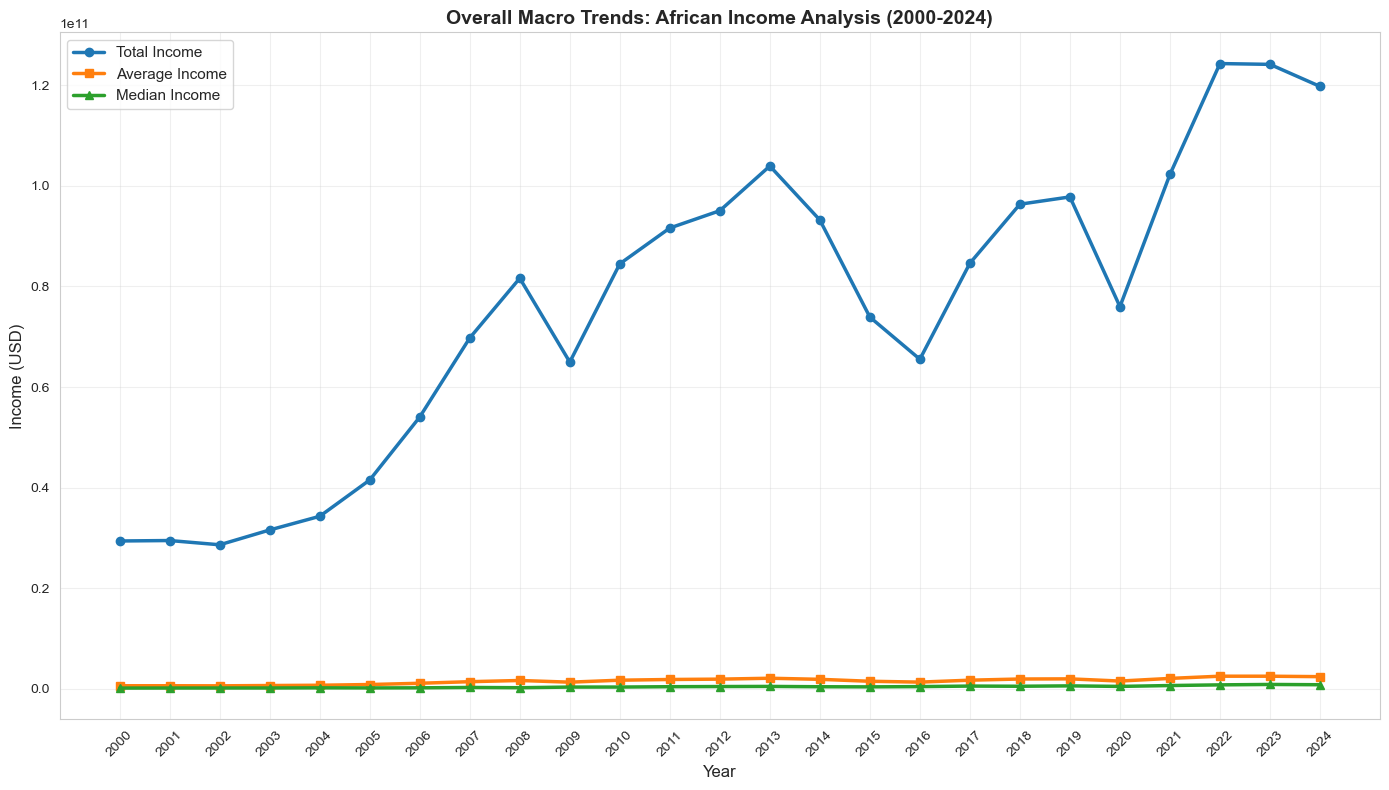

In [29]:
# Calculate macro trends across all countries by year
macro_trends = pd.DataFrame(index=years)
macro_trends.index.name = 'Year'

macro_trends['Total Income'] = [data[year].sum() for year in year_columns]
macro_trends['Average Income'] = [data[year].mean() for year in year_columns]
macro_trends['Median Income'] = [data[year].median() for year in year_columns]

# Create multi-line chart
plt.figure(figsize=(14, 8))
sns.set_style('whitegrid')

xs_int = [int(x) for x in years]

plt.plot(xs_int, macro_trends['Total Income'].values, marker='o', linewidth=2.5, label='Total Income', color='#1f77b4')
plt.plot(xs_int, macro_trends['Average Income'].values, marker='s', linewidth=2.5, label='Average Income', color='#ff7f0e')
plt.plot(xs_int, macro_trends['Median Income'].values, marker='^', linewidth=2.5, label='Median Income', color='#2ca02c')

plt.title('Overall Macro Trends: African Income Analysis (2000-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Income (USD)', fontsize=12)
plt.xticks(xs_int, rotation=45)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2. Small Multiples Grid (Unmasking the Smaller Economies)

Best For: Displaying individual country trajectories clearly, without the scale being crushed by the giants (Algeria/Angola).

Why it shines: By creating a grid of individual subplots (e.g., a $2 \times 5$ grid) where each country has its own dynamic Y-axis, you can see if Burundi or Benin is quietly experiencing explosive percentage-based growth.


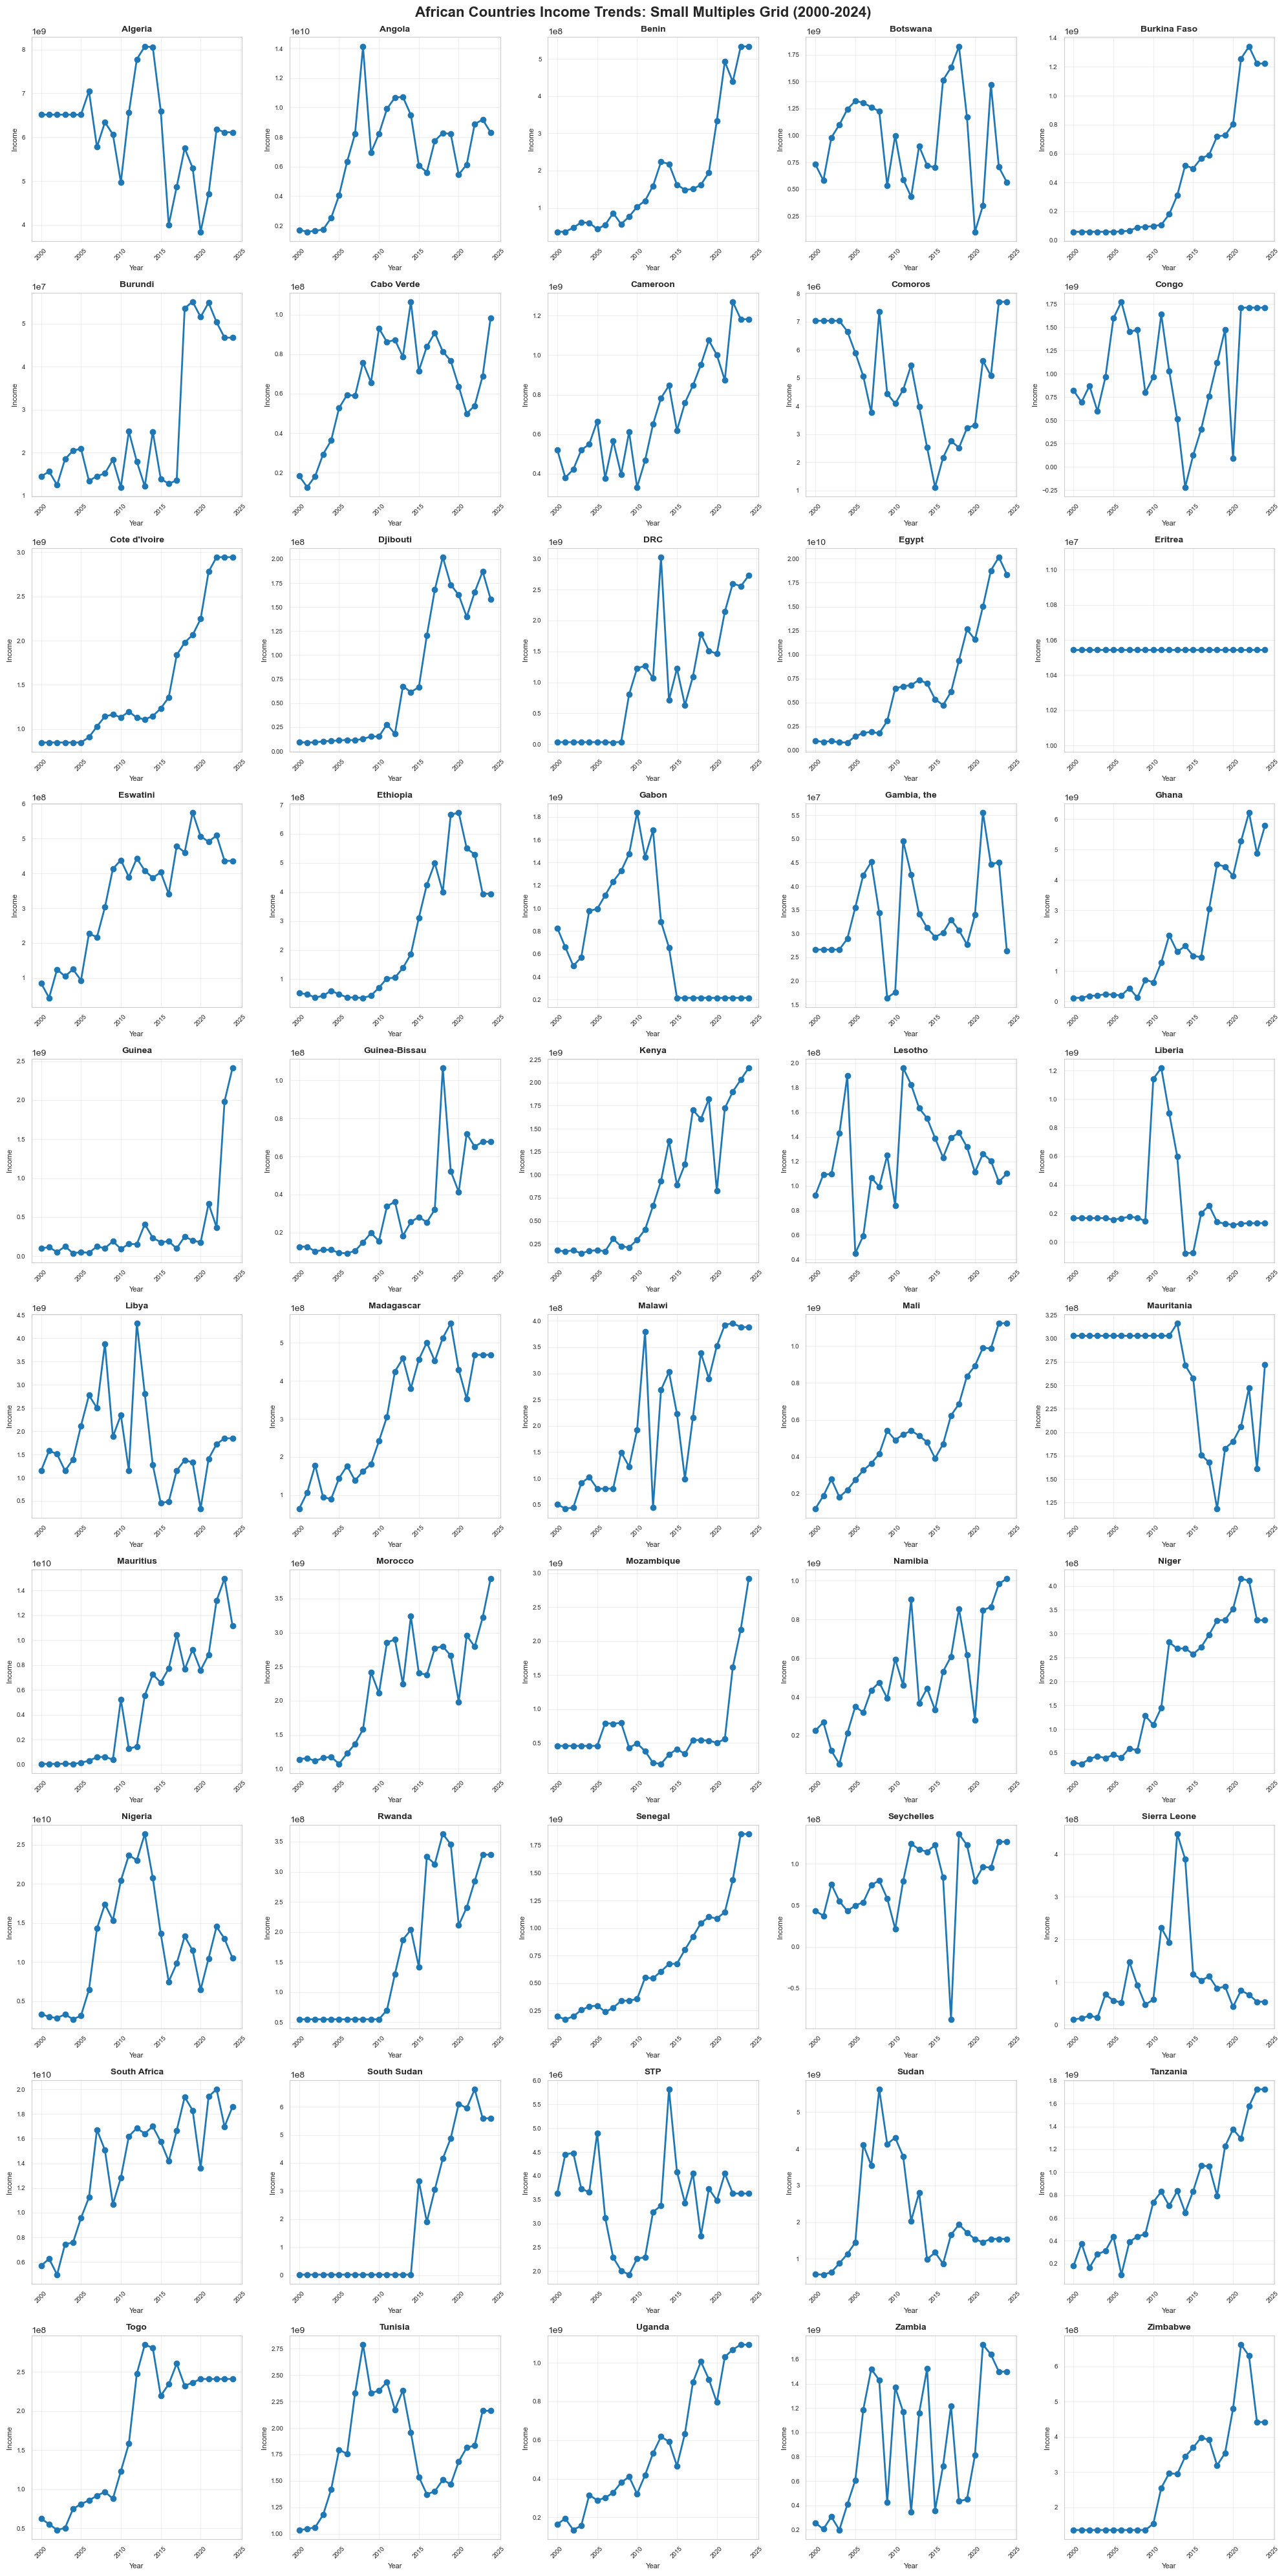

In [30]:
# Create Small Multiples Grid to visualize all African countries
plt.close('all')

# Get all countries (not just top 10)
all_countries = data['Country English'].unique()
n_countries = len(all_countries)

# Create grid layout
n_cols = 5
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

# Plot each country
for idx, country in enumerate(all_countries):
    ax = axes[idx]
    country_data = data[data['Country English'] == country][year_columns].iloc[0].values
    xs_int = [int(x) for x in year_columns]
    
    ax.plot(xs_int, country_data, marker='o', linewidth=2, color='#1f77b4')
    ax.set_title(country, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Income', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(n_countries, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('African Countries Income Trends: Small Multiples Grid (2000-2024)', 
             fontsize=16, fontweight='bold', y=0.995)
fig.tight_layout()
plt.show()

3. Heatmap Matrix (Spotting Spikes and Anomalies)

Best For: Quickly comparing growth distributions and spotting specific "peak" or "drop" years without messy overlapping lines.

Why it shines: It transforms raw numbers into a grid of color intensities. You'll instantly see continuous structural blocks of color shift across years like 2016 or 2020.


C:\Users\MCHARO\AppData\Local\Temp\ipykernel_19076\1278174660.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_arr = stats.zscore(df_heat.values, axis=1, nan_policy='omit')


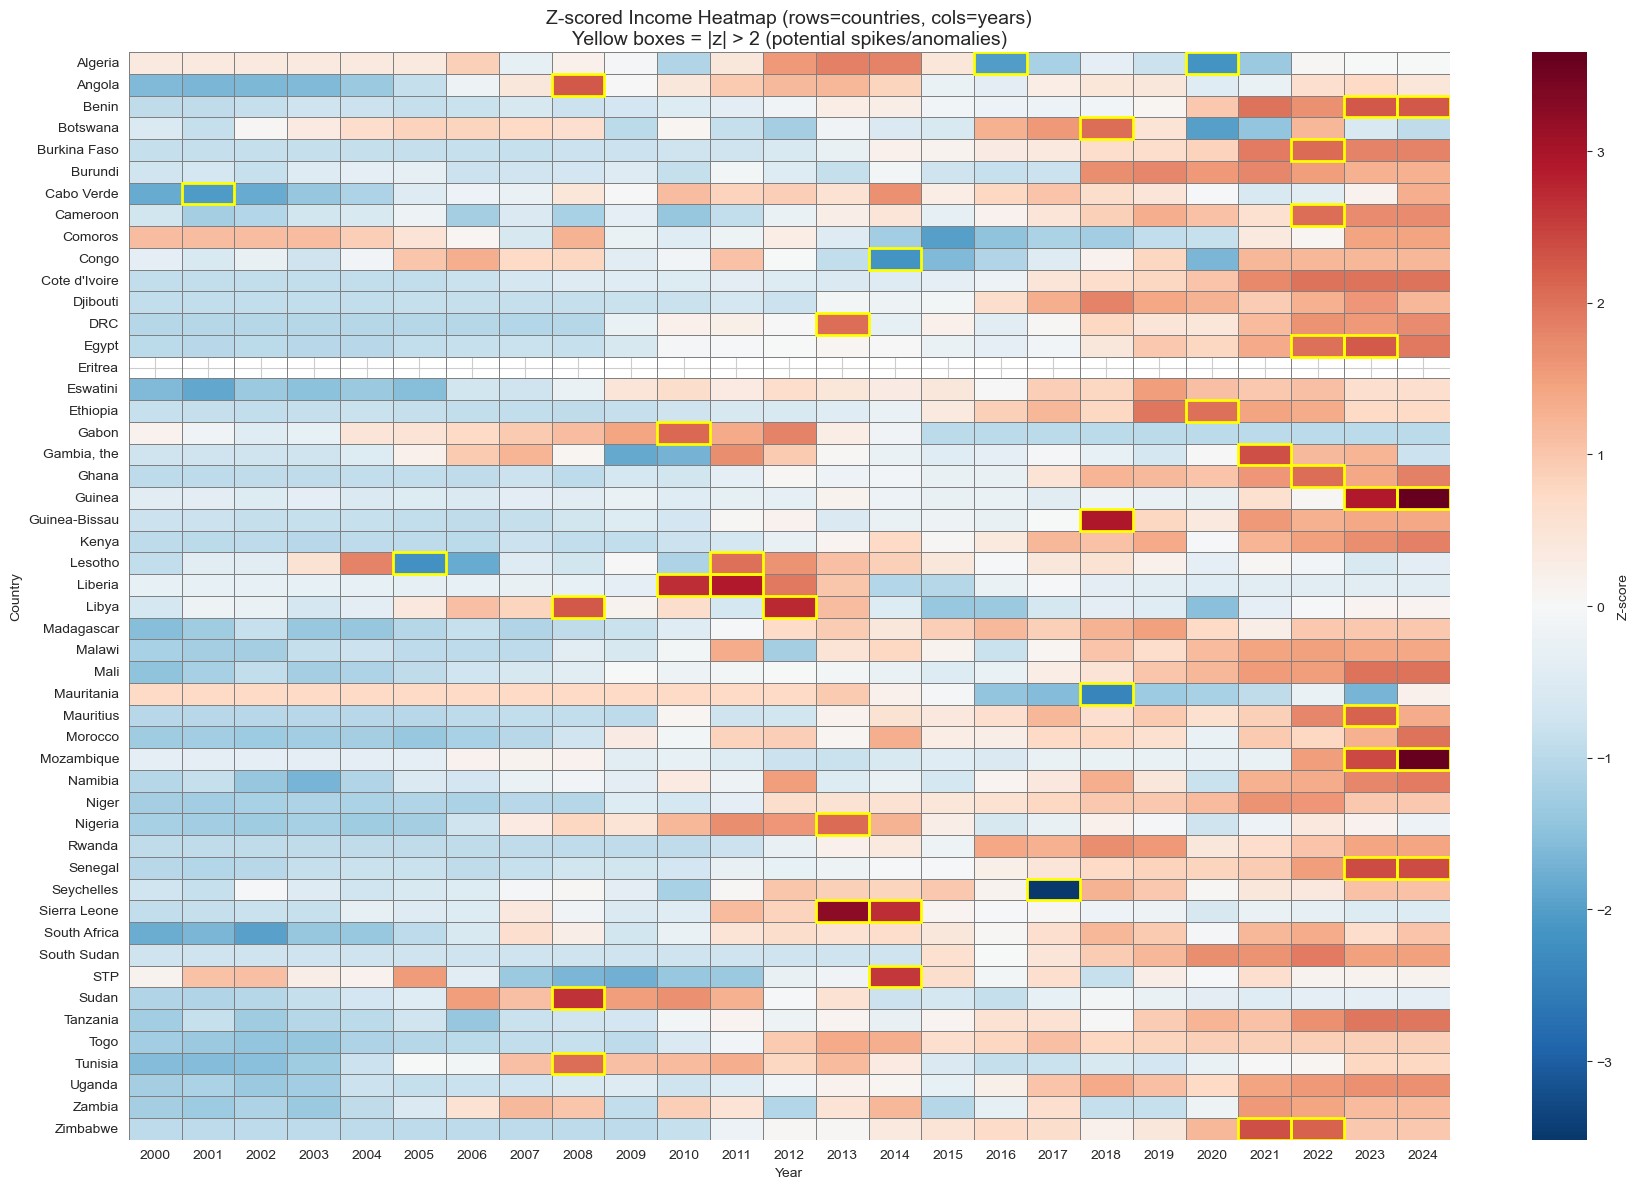

In [33]:
# Heatmap Matrix to spot spikes/anomalies (z-score based)
# Uses existing variables: data, years, sns, plt, np, stats

df_heat = data.set_index('Country English')[years].astype(float)

# compute z-scores per country (row-wise)
# compute z-scores per country (row-wise) and return a DataFrame with same index/columns
z_arr = stats.zscore(df_heat.values, axis=1, nan_policy='omit')
z_scores = pd.DataFrame(z_arr, index=df_heat.index, columns=df_heat.columns)
z_values = z_scores.values

# anomaly threshold
thresh = 2.0
anoms = np.abs(z_values) > thresh

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(z_scores, cmap='RdBu_r', center=0, cbar_kws={'label': 'Z-score'}, ax=ax, linewidths=0.5, linecolor='gray')

# highlight anomalies with yellow rectangles
for r, c in zip(*np.where(anoms)):
    ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor='yellow', lw=2))

ax.set_title('Z-scored Income Heatmap (rows=countries, cols=years)\nYellow boxes = |z| > 2 (potential spikes/anomalies)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

4. Grouped or Stacked Bar Chart (Snapshots of Time)

Best For: Comparing structural composition at key turning points (e.g., comparing everyone's positions explicitly in 2000, 2015, and 2024).

Why it shines: Plotting 25 continuous years on a bar chart gets crowded, but isolating 3 or 4 symbolic years shows a clear picture of shifting market shares over long eras.

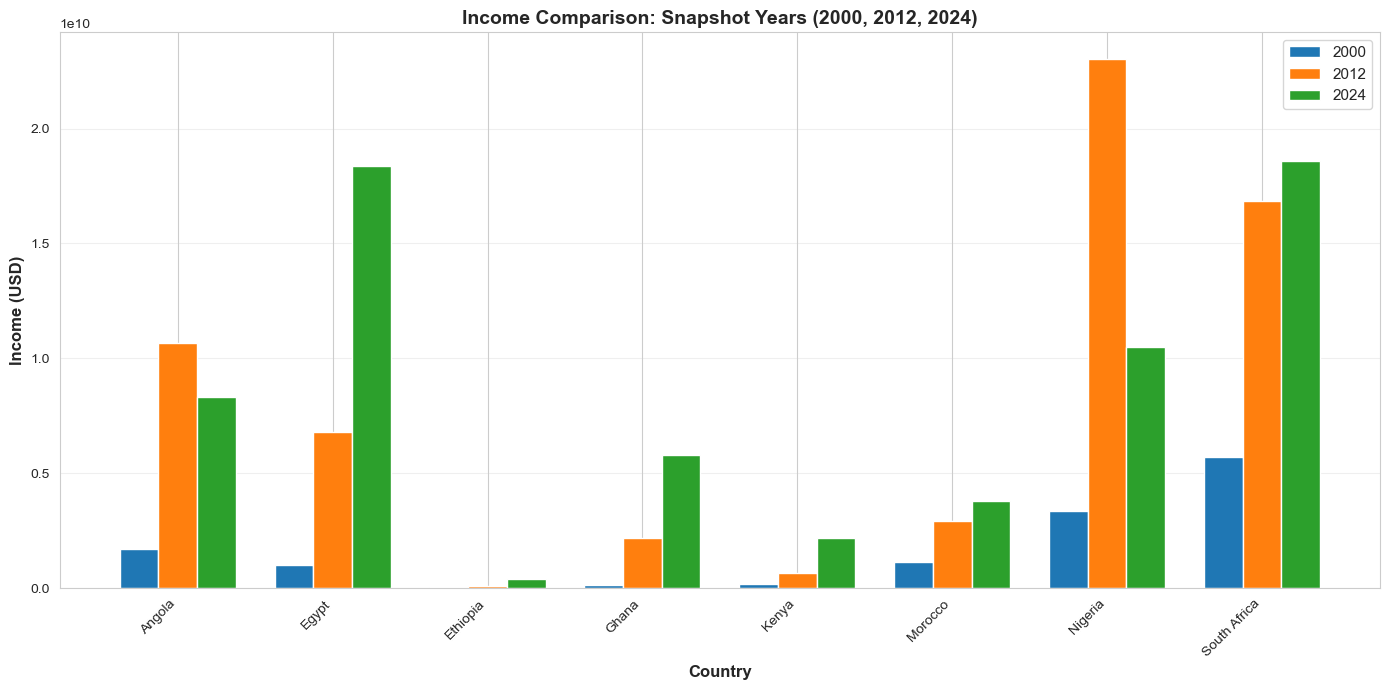

In [36]:
# Grouped or Stacked Bar Chart (Snapshots of Time) - comparing select years
plt.close('all')

# Select snapshot years and countries including Kenya
snapshot_years = ['2000', '2012', '2024']
selected_countries = ['South Africa', 'Egypt', 'Nigeria', 'Angola', 'Kenya', 'Ethiopia', 'Ghana', 'Morocco']

# Filter data
chart_data = data[data['Country English'].isin(selected_countries)].set_index('Country English')[snapshot_years]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(chart_data.index))
width = 0.25

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, year in enumerate(snapshot_years):
    ax.bar(x + i*width, chart_data[year].values, width, label=year, color=colors[i])

ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Income (USD)', fontsize=12, fontweight='bold')
ax.set_title('Income Comparison: Snapshot Years (2000, 2012, 2024)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(chart_data.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.show()

5. Interactive Plotly Dashboard with Time Slider

What it is: A dynamic HTML-based visualization where the user can slide a timeline handle at the bottom back and forth to see bar charts or bubble sizes change instantly.

Why use it: Perfect for embedding into web pages, Jupyter Notebooks, or sharing as an interactive standalone file where users want to hover over datapoints to see exact values.

In [39]:
import plotly.express as px

latest_year = year_columns[-1]
top_n = 20

top_countries = data.sort_values(by=latest_year, ascending=False).head(top_n)['Country English']
df_top = data[data['Country English'].isin(top_countries)].copy()

df_long = df_top.melt(
    id_vars=['Country English'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Income'
)
df_long['Year'] = df_long['Year'].astype(int)

fig = px.bar(
    df_long,
    x='Country English',
    y='Income',
    color='Country English',
    animation_frame='Year',
    animation_group='Country English',
    range_y=[0, df_long['Income'].max() * 1.05],
    title=f'Top {top_n} African Countries Income Evolution (2000-2024)',
    labels={'Country English': 'Country', 'Income': 'Income (USD)'}
)

fig.update_layout(
    showlegend=False,
    xaxis_tickangle=-45,
    transition={'duration': 500},
    margin=dict(l=40, r=40, t=80, b=140)
)
fig.update_xaxes(categoryorder='total descending')
fig.show()

In [44]:
time_series = data.set_index('Country English')[year_columns].astype(float)

n_years = len(year_columns)
years_int = np.array([int(y) for y in year_columns])

start_income = time_series.iloc[:, 0]
end_income = time_series.iloc[:, -1]

total_growth = end_income / start_income.replace({0: np.nan})
cagr = total_growth.pow(1 / (n_years - 1)) - 1

yoy = time_series.pct_change(axis=1).iloc[:, 1:]
volatility = yoy.std(axis=1)
recent_start = time_series.iloc[:, -5]
recent_5yr_cagr = (end_income / recent_start.replace({0: np.nan})).pow(1 / 4) - 1

def log_trend_slope(row):
    mask = row.notna()
    if mask.sum() < 2:
        return np.nan
    return stats.linregress(years_int[mask], np.log(row[mask].values)).slope

trend_slope = time_series.apply(log_trend_slope, axis=1)
peak_year = time_series.idxmax(axis=1).astype(int)
drawdown = (time_series.div(time_series.cummax(axis=1)) - 1).min(axis=1)
last_3yr_mean = time_series.iloc[:, -3:].mean(axis=1)

cluster_features = pd.DataFrame({
    'Growth Multiple': total_growth,
    'CAGR': cagr,
    '5yr CAGR': recent_5yr_cagr,
    'Average YoY': yoy.mean(axis=1),
    'Volatility': volatility,
    'Log Trend Slope': trend_slope,
    'Max Drawdown': drawdown,
    'Peak Year': peak_year,
    'Last 3yr Mean': last_3yr_mean
})

cluster_features = cluster_features.dropna()

print("Kenya features:")
print(cluster_features.loc[['Kenya']])

cluster_features.head()

Kenya features:
                 Growth Multiple      CAGR  5yr CAGR  Average YoY  Volatility  \
Country English                                                                 
Kenya                  12.131819  0.109593  0.272498     0.167783    0.371707   

                 Log Trend Slope  Max Drawdown  Peak Year  Last 3yr Mean  
Country English                                                           
Kenya                   0.129686     -0.547806       2024   2.031225e+09  


C:\Users\MCHARO\AppData\Local\Temp\ipykernel_19076\2641376361.py:21: RuntimeWarning:

invalid value encountered in log



,Growth Multiple,CAGR,5yr CAGR,Average YoY,Volatility,Log Trend Slope,Max Drawdown,Peak Year,Last 3yr Mean
Country English,,,,,,,,,
Algeria,0.938344,-0.002648,0.123193,0.013110,0.176586,-0.010059,-0.524136,2013,6.136885e+09
Angola,4.847972,0.067985,0.110896,0.111776,0.307696,0.057799,-0.613861,2008,8.791579e+09
Benin,14.886441,0.119093,0.124401,0.151443,0.272552,0.111669,-0.345199,2023,5.017110e+08
Botswana,0.774258,-0.010604,0.525644,0.256186,0.934420,-0.017821,-0.942919,2018,9.140710e+08
Burkina Faso,20.873064,0.134966,0.110606,0.156677,0.248087,0.161490,-0.088055,2022,1.262557e+09


C:\Users\MCHARO\AppData\Local\Temp\ipykernel_19076\2007454270.py:26: RuntimeWarning:

invalid value encountered in log

c:\Users\MCHARO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



Cluster counts:
Cluster
0    27
1     1
2     6
3    13
Name: count, dtype: int64

Cluster centroid summaries:
             CAGR  5yr_CAGR  Volatility  Log Trend Slope  Drawdown  \
Cluster                                                              
0        0.097234  0.071471    0.630373         0.107154 -0.454381   
1        0.252917 -0.021745   27.173586         0.305549 -0.431121   
2        0.049846  0.523656    0.800580         0.025641 -0.839010   
3        0.020714  0.049909    0.337206         0.011703 -0.630430   

           Peak Year  
Cluster               
0        2020.777778  
1        2022.000000  
2        2020.833333  
3        2011.230769  


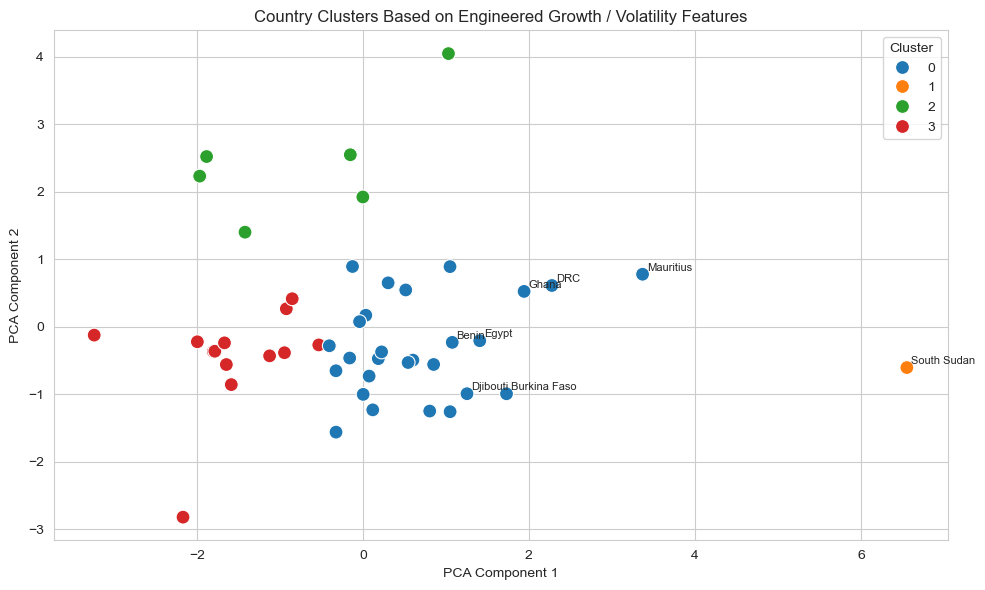

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

time_series = data.set_index('Country English')[year_columns].astype(float)

n_years = len(year_columns)
years_int = np.array([int(y) for y in year_columns])

start_income = time_series.iloc[:, 0]
end_income = time_series.iloc[:, -1]

total_growth = end_income / start_income
cagr = total_growth.pow(1 / (n_years - 1)) - 1

yoy = time_series.pct_change(axis=1).iloc[:, 1:]
volatility = yoy.std(axis=1)

recent_start = time_series.iloc[:, -5]
recent_5yr_cagr = (end_income / recent_start).pow(1 / 4) - 1

def log_trend_slope(row):
    valid_mask = row.notna().values
    if valid_mask.sum() < 2:
        return np.nan
    return stats.linregress(years_int[valid_mask], np.log(row.values[valid_mask])).slope

trend_slope = time_series.apply(log_trend_slope, axis=1)
peak_year = time_series.idxmax(axis=1).astype(int)
drawdown = (time_series / time_series.cummax(axis=1) - 1).min(axis=1)

feature_cols = [
    'CAGR',
    '5yr_CAGR',
    'Volatility',
    'Log Trend Slope',
    'Drawdown',
    'Peak Year'
]

cluster_features = pd.DataFrame({
    'CAGR': cagr,
    '5yr_CAGR': recent_5yr_cagr,
    'Volatility': volatility,
    'Log Trend Slope': trend_slope,
    'Drawdown': drawdown,
    'Peak Year': peak_year
})

cluster_features = cluster_features.dropna()

scaler = StandardScaler()
X = scaler.fit_transform(cluster_features)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_features['Cluster'] = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
cluster_features[['PC1', 'PC2']] = pca.fit_transform(X)

print('Cluster counts:')
print(cluster_features['Cluster'].value_counts().sort_index())

print('\nCluster centroid summaries:')
print(cluster_features.groupby('Cluster')[feature_cols].mean())

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=cluster_features,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='tab10',
    s=100
)
ax.set_title('Country Clusters Based on Engineered Growth / Volatility Features')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')

for country, row in cluster_features.sort_values('PC1', ascending=False).head(8).iterrows():
    ax.text(row['PC1'] + 0.05, row['PC2'] + 0.05, country, fontsize=8)

plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

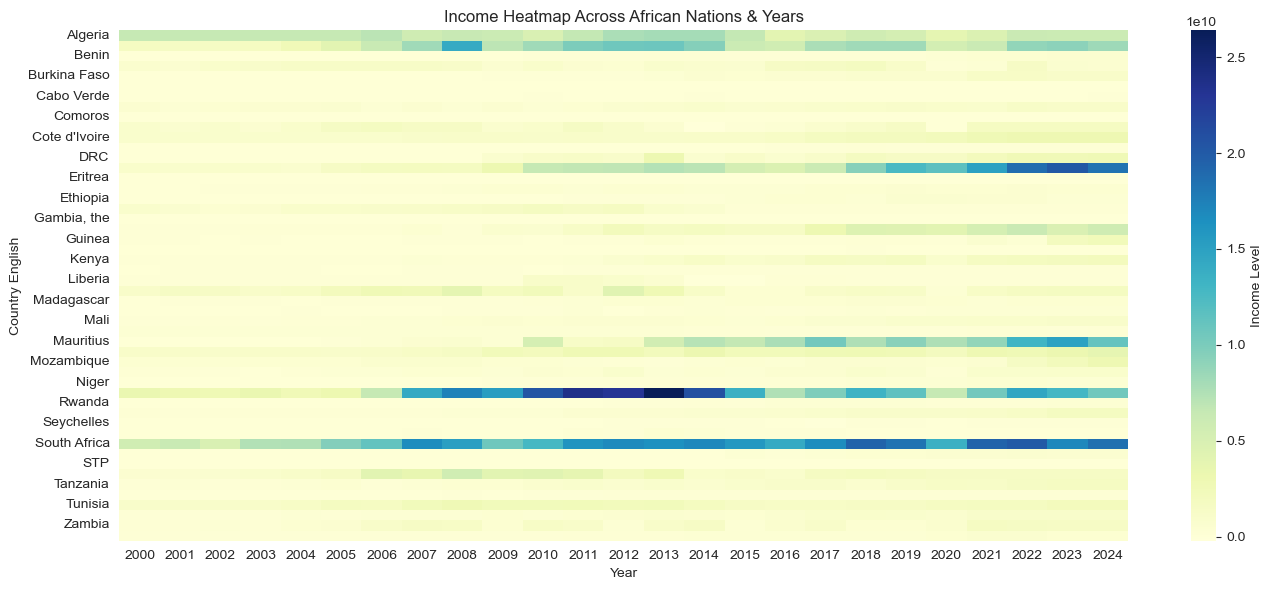

In [20]:
plt.figure(figsize=(14,6))
df_heat = data.set_index('Country English')[years].astype(float)

sns.heatmap(df_heat, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Income Level'})
plt.title("Income Heatmap Across African Nations & Years")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [ ]:
output_path = 'df_clean_export.xlsx'
df_clean.to_excel(output_path, index=False)
print(f"Exported df_clean to {r"C:\Users\MCHARO\OneDrive\Desktop\Income Analysis"}")

Exported df_clean to C:\Users\MCHARO\OneDrive\Desktop\Income Analysis


In [ ]:
df_clean.to_excel(r'C:\Users\MCHARO\OneDrive\Desktop\Income Analysis\df_clean_export.xlsx', index=False)
print(f"Exported df_clean to C:\\Users\\MCHARO\\OneDrive\\Desktop\\Income Analysis")

Exported df_clean to C:\Users\MCHARO\OneDrive\Desktop\Income Analysis
